# US interest rates and defaults by monetary regime

**Reproducible empirical notebook — data snapshot generated 16 July 2026**

This notebook studies whether the sign of the relationship between interest rates and US credit deterioration changes across monetary regimes and default definitions. It deliberately distinguishes a simple correlation from a lagged, macro-controlled association.

The notebook uses public Federal Reserve/FRED data. It is an exploratory macro study, not a causal estimate and not an IFRS 9 model approval document.

## Research questions

1. Does the rate/default sign change across US monetary regimes?
2. Does it depend on whether default is measured as delinquency or net charge-off?
3. Does the relationship change at zero-, one- and two-year lags?
4. Does replacing the federal funds rate with a borrower-facing rate make the sign more stable?

The central limitation is identification: the Federal Reserve often cuts rates when it expects defaults to rise. Therefore, a negative coefficient can reflect the policy response rather than a protective effect of low rates.

In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("data_us_rates_defaults")
DATA_DIR.mkdir(exist_ok=True)

SERIES = {
    "business_delinquency": "DRBLACBS",
    "business_chargeoff": "CORBLACBS",
    "mortgage_delinquency": "DRSFRMACBS",
    "mortgage_chargeoff": "CORSFRMACBS",
    "credit_card_delinquency": "DRCCLACBS",
    "credit_card_chargeoff": "CORCCACBS",
    "consumer_delinquency": "DRCLACBS",
    "fed_funds": "FEDFUNDS",
    "prime_rate": "MPRIME",
    "mortgage_rate": "MORTGAGE30US",
    "credit_card_apr": "TERMCBCCALLNS",
    "cpi": "CPIAUCSL",
    "unemployment": "UNRATE",
    "real_gdp": "GDPC1",
}

LABELS = {
    "business_delinquency": "Business-loan delinquency rate",
    "business_chargeoff": "Business-loan net charge-off rate",
    "mortgage_delinquency": "Single-family mortgage delinquency rate",
    "mortgage_chargeoff": "Single-family mortgage net charge-off rate",
    "credit_card_delinquency": "Credit-card delinquency rate",
    "credit_card_chargeoff": "Credit-card net charge-off rate",
}
DEFAULT_COLS = list(LABELS)

BORROWER_RATE_MAP = {
    "business_delinquency": "prime_rate",
    "business_chargeoff": "prime_rate",
    "mortgage_delinquency": "mortgage_rate",
    "mortgage_chargeoff": "mortgage_rate",
    "credit_card_delinquency": "credit_card_apr",
    "credit_card_chargeoff": "credit_card_apr",
}

REGIMES = [
    ("Conventional / Great Moderation", "1987Q1", "2000Q4"),
    ("Low-rate credit boom", "2001Q1", "2007Q2"),
    ("GFC and ZLB", "2007Q3", "2015Q4"),
    ("Policy normalization", "2016Q1", "2019Q4"),
    ("Pandemic ZLB", "2020Q1", "2021Q4"),
    ("Inflation tightening", "2022Q1", "2099Q4"),
]


Libraries, series identifiers and regime definitions loaded.


## Data and default definitions

- **Delinquency:** Federal Reserve bank data define delinquent loans as at least 30 days past due and still accruing, plus loans in non-accrual status.
- **Net charge-off:** loans removed from banks' books, net of recoveries, annualized as a percentage of average loans.
- Business-loan, mortgage and credit-card measures do not cover exactly the same borrowers or start dates.

Primary sources: [Federal Reserve charge-off and delinquency release](https://www.federalreserve.gov/releases/chargeoff/), [FRED release table](https://fred.stlouisfed.org/release?rid=231), [Federal funds rate](https://fred.stlouisfed.org/series/FEDFUNDS), [bank prime rate](https://fred.stlouisfed.org/series/MPRIME), [30-year mortgage rate](https://fred.stlouisfed.org/series/MORTGAGE30US), and [credit-card APR](https://fred.stlouisfed.org/series/TERMCBCCALLNS).

In [2]:
def get_series(series_id):
    """Download one FRED CSV and keep a local cache."""
    path = DATA_DIR / f"{series_id}.csv"
    if not path.exists():
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        with urllib.request.urlopen(url, timeout=60) as response:
            path.write_bytes(response.read())
    x = pd.read_csv(path)
    x.columns = ["date", series_id]
    x["date"] = pd.to_datetime(x["date"])
    x[series_id] = pd.to_numeric(x[series_id], errors="coerce")
    return x.set_index("date")[series_id]

def quarterly(series):
    q = series.resample("QE").mean()
    q.index = q.index.to_period("Q")
    return q

def build_data():
    columns = {name: quarterly(get_series(sid)) for name, sid in SERIES.items()}
    data = pd.concat(columns, axis=1).sort_index()
    data["inflation_yoy"] = 100 * (data["cpi"] / data["cpi"].shift(4) - 1)
    data["gdp_growth_yoy"] = 100 * (data["real_gdp"] / data["real_gdp"].shift(4) - 1)
    data["unemployment_change_yoy"] = data["unemployment"] - data["unemployment"].shift(4)
    for rate in ["fed_funds", "prime_rate", "mortgage_rate", "credit_card_apr"]:
        data[f"{rate}_change_yoy_lag1"] = data[rate].shift(1) - data[rate].shift(5)
    for col in DEFAULT_COLS:
        data[f"{col}_change_yoy"] = data[col] - data[col].shift(4)
    return data

df = build_data()
coverage = pd.DataFrame([
    {"Default definition": LABELS[c], "Start": str(df[c].first_valid_index()),
     "Latest": str(df[c].last_valid_index()), "Frequency": "Quarterly"}
    for c in DEFAULT_COLS
])
coverage


Default definition,Start,Latest,Frequency
Business-loan delinquency rate,1987Q1,2026Q1,Quarterly
Business-loan net charge-off rate,1985Q1,2026Q1,Quarterly
Single-family mortgage delinquency rate,1991Q1,2026Q1,Quarterly
Single-family mortgage net charge-off rate,1991Q1,2026Q1,Quarterly
Credit-card delinquency rate,1991Q1,2026Q1,Quarterly
Credit-card net charge-off rate,1985Q1,2026Q1,Quarterly


## Regime definitions

The dates are fixed **before looking at the regression signs** and are based on broad US monetary-policy episodes. They are not statistically estimated breakpoints. The split is intentionally granular after 2015, but that creates very small samples; estimates with fewer than 20 observations are marked by a triangle.

In [3]:
regime_table = pd.DataFrame(REGIMES, columns=['Regime','Start','End'])
regime_table.loc[regime_table.End == '2099Q4','End'] = str(df[DEFAULT_COLS].dropna(how='all').last_valid_index())
regime_table

Regime,Start,End,Economic interpretation
Conventional / Great Moderation,1987Q1,2000Q4,Conventional policy; disinflation aftermath and Great Moderation
Low-rate credit boom,2001Q1,2007Q2,Post-dot-com easing and pre-GFC credit/housing expansion
GFC and ZLB,2007Q3,2015Q4,"Financial crisis, emergency easing and near-zero policy rate"
Policy normalization,2016Q1,2019Q4,Gradual rate normalization before COVID-19
Pandemic ZLB,2020Q1,2021Q4,"Pandemic recession, policy support and forbearance"
Inflation tightening,2022Q1,2026Q1,High inflation and rapid monetary tightening


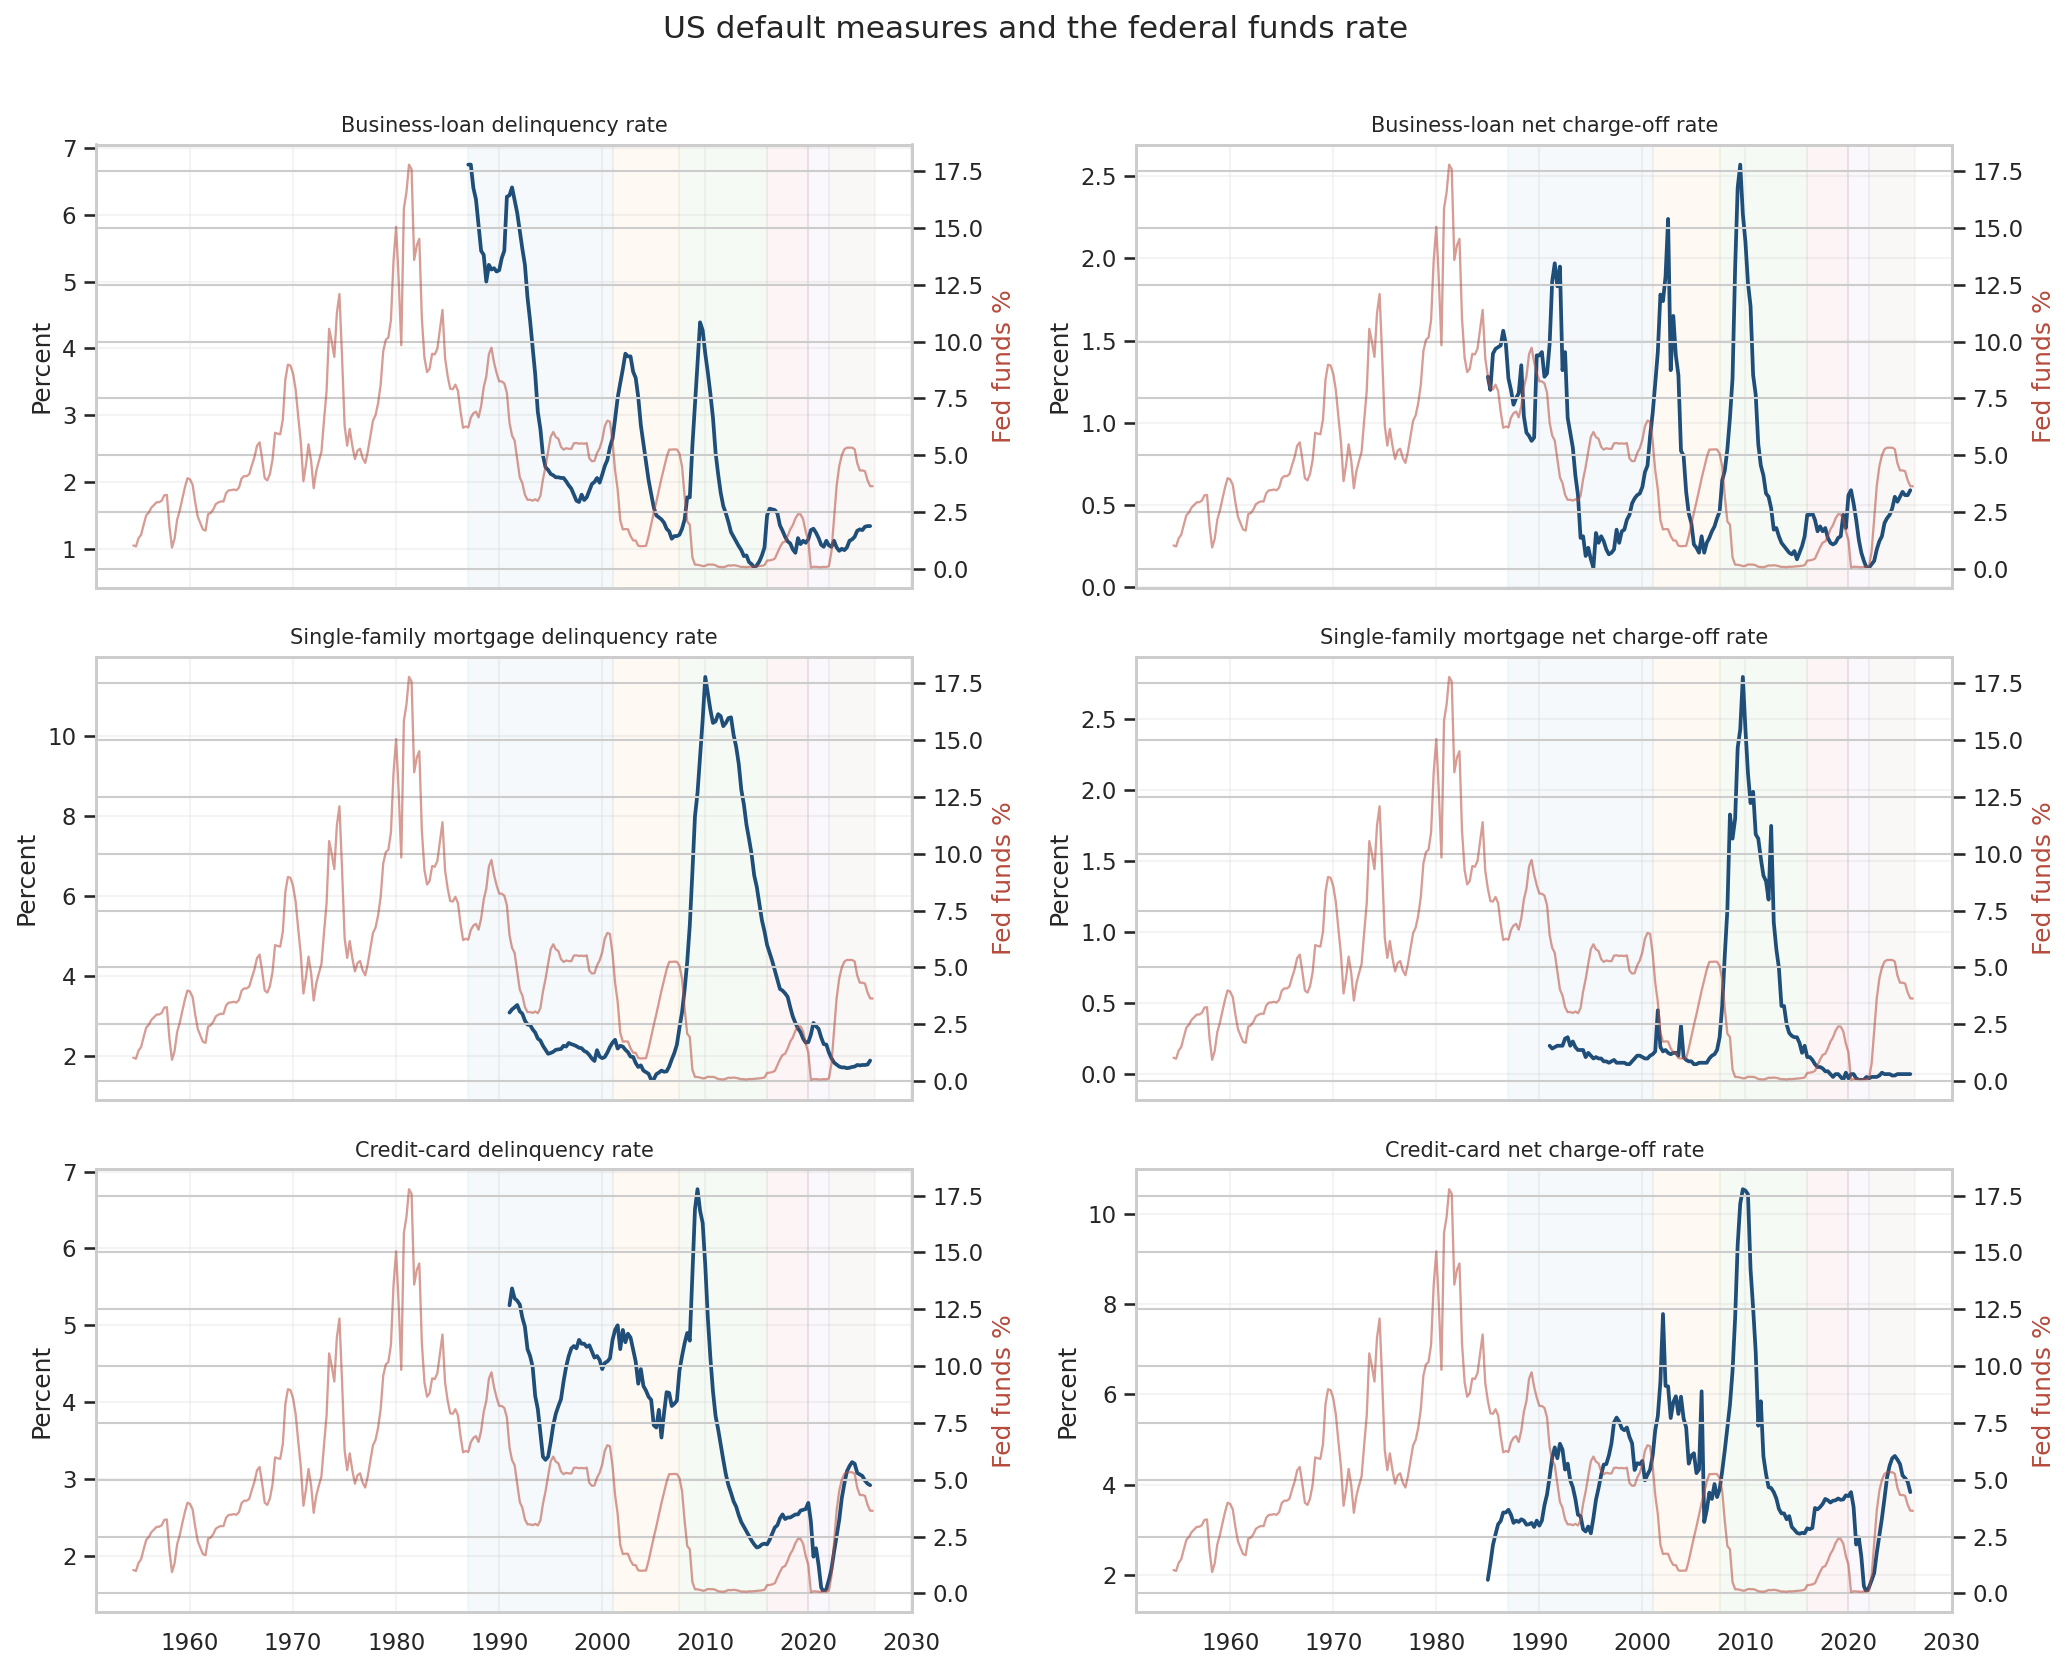

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
period_x = df.index.to_timestamp()
colors = sns.color_palette("tab10", len(REGIMES))
for ax, col in zip(axes.flat, DEFAULT_COLS):
    ax.plot(period_x, df[col], color="#1f4e79", lw=1.8, label="Default measure")
    ax.set_title(LABELS[col], fontsize=10)
    ax.set_ylabel("Percent")
    ax.grid(alpha=.2)
    ax2 = ax.twinx()
    ax2.plot(period_x, df.fed_funds, color="#b64b3c", alpha=.55, lw=1.1, label="Fed funds")
    ax2.set_ylabel("Fed funds %", color="#b64b3c")
    for (regime, start, end), shade in zip(REGIMES, colors):
        lo = pd.Period(start, "Q").start_time
        hi = min(pd.Period(end, "Q").end_time, period_x.max())
        ax.axvspan(lo, hi, color=shade, alpha=.045)
fig.suptitle("US default measures and the federal funds rate", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()


## Raw Pearson correlations at zero-, one- and two-year lags

To make the results comparable across default definitions, the following tables report ordinary Pearson correlations, bounded between −1 and +1. Both default rates and the federal funds rate are used in their **absolute percentage levels**.

The three comparisons are:

- **No lag:** $Corr(DefaultRate_t, Rate_t)$.
- **1-year lag:** $Corr(DefaultRate_t, Rate_{t-4})$.
- **2-year lag:** $Corr(DefaultRate_t, Rate_{t-8})$.

Deep blue represents a strong negative correlation, white represents approximately zero correlation, and deep red represents a strong positive correlation. These are raw correlations without GDP, unemployment or inflation controls. The regime is assigned using the date of the default outcome, so lagged rate observations can come from the preceding regime.

Level correlations are easy to interpret but can be inflated by persistence, common trends and policy reactions. They are therefore descriptive; the controlled rolling regressions below provide a more defensible view of time-varying rate sensitivity.

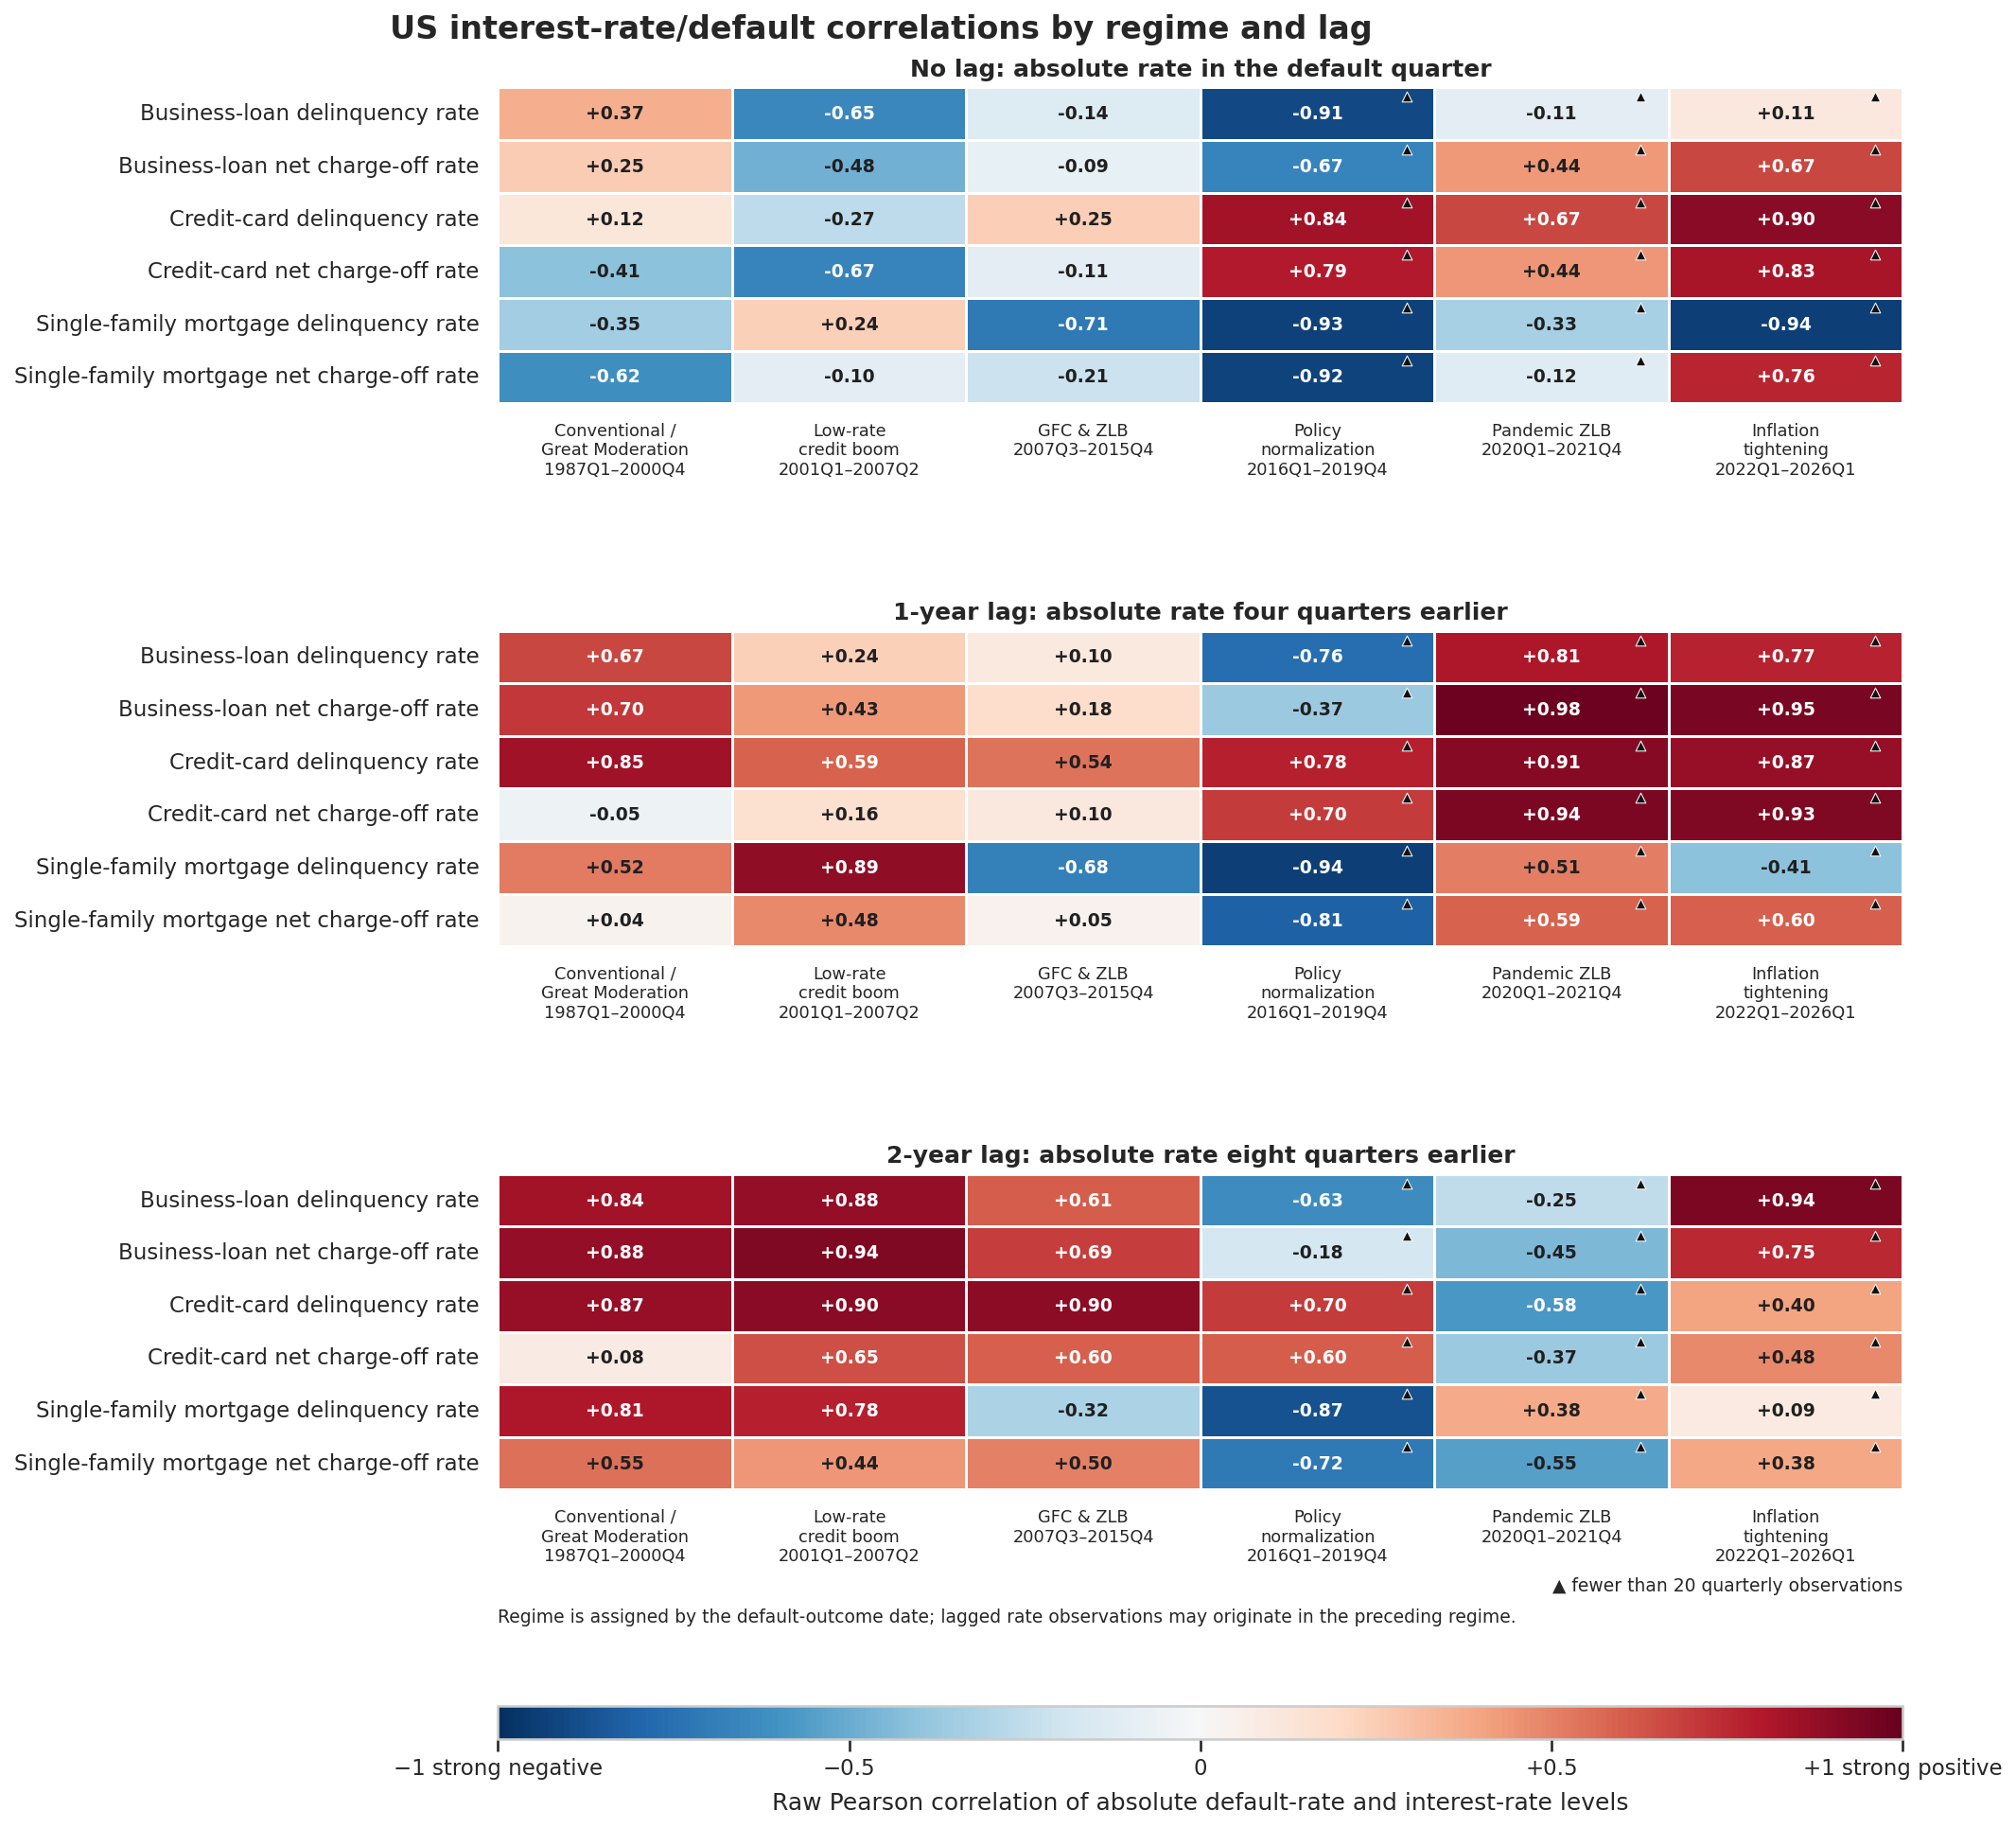

In [5]:
import matplotlib as mpl

def raw_correlation_results(data, rate_col="fed_funds"):
    """Pearson correlations of absolute default-rate and interest-rate levels."""
    records = []
    for lag_years in [0, 1, 2]:
        rate_level = data[rate_col].shift(4*lag_years)
        for default_col in DEFAULT_COLS:
            for regime, start, end in REGIMES:
                pair = pd.concat([data[default_col].rename("default_rate"),
                                  rate_level.rename("rate_level")], axis=1)
                pair = pair.loc[pd.Period(start, "Q"):pd.Period(end, "Q")].dropna()
                records.append({
                    "lag_years": lag_years,
                    "default_definition": LABELS[default_col],
                    "regime": regime,
                    "correlation": pair.default_rate.corr(pair.rate_level) if len(pair) >= 4 else np.nan,
                    "n": len(pair),
                })
    return pd.DataFrame(records)

def correlation_heatmap(corr_data, lag_years, title, ax):
    x = corr_data[corr_data.lag_years == lag_years]
    order = [r[0] for r in REGIMES]
    corr = x.pivot(index="default_definition", columns="regime", values="correlation").reindex(columns=order)
    nobs = x.pivot(index="default_definition", columns="regime", values="n").reindex(columns=order)
    labels = corr.map(lambda v: "" if pd.isna(v) else f"{v:+.2f}")

    sns.heatmap(corr, annot=labels, fmt="", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, linewidths=1.2, linecolor="white",
                cbar=False, ax=ax, annot_kws={"fontsize": 9, "fontweight": "bold"})
    for text, value in zip(ax.texts, corr.to_numpy().ravel()):
        text.set_color("white" if np.isfinite(value) and abs(value) >= .58 else "#202020")
    for i in range(nobs.shape[0]):
        for j in range(nobs.shape[1]):
            if pd.notna(nobs.iloc[i, j]) and nobs.iloc[i, j] < 20:
                ax.scatter(j+.88, i+.18, marker="^", s=26,
                           color="#111111", edgecolor="white", linewidth=.5, zorder=5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([
        "Conventional /\nGreat Moderation\n1987Q1–2000Q4",
        "Low-rate\ncredit boom\n2001Q1–2007Q2",
        "GFC & ZLB\n2007Q3–2015Q4",
        "Policy\nnormalization\n2016Q1–2019Q4",
        "Pandemic ZLB\n2020Q1–2021Q4",
        "Inflation\ntightening\n2022Q1–2026Q1",
    ], rotation=0, ha="center", fontsize=8.5)

corr_results = raw_correlation_results(df)
fig, axes = plt.subplots(3, 1, figsize=(15, 13))
correlation_heatmap(corr_results, 0, "No lag: absolute rate in the default quarter", axes[0])
correlation_heatmap(corr_results, 1, "1-year lag: absolute rate four quarters earlier", axes[1])
correlation_heatmap(corr_results, 2, "2-year lag: absolute rate eight quarters earlier", axes[2])

norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="RdBu_r")
cax = fig.add_axes([.32, .045, .66, .018])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_ticks([-1, -.5, 0, .5, 1])
cbar.set_ticklabels(["−1 strong negative", "−0.5", "0", "+0.5", "+1 strong positive"])
cbar.set_label("Raw Pearson correlation of absolute default-rate and interest-rate levels", labelpad=6)
fig.suptitle("US interest-rate/default correlations by regime and lag",
             fontsize=16, fontweight="bold")
fig.text(.98, .125, "▲ fewer than 20 quarterly observations", ha="right", fontsize=9)
fig.text(.32, .108,
         "Regime is assigned by the default-outcome date; lagged rate observations may originate in the preceding regime.",
         ha="left", fontsize=9)
fig.subplots_adjust(left=.32, right=.98, top=.94, bottom=.18, hspace=.72)
plt.show()


## Supplementary change-based regression specifications

The notebook estimates two regressions separately within each regime and default definition.

Naïve levels regression:

$$D_t = \alpha + \beta r_t + \varepsilon_t$$

Lagged-change regression with macro controls:

$$\Delta_4 D_t = \alpha + \beta\Delta_4r_{t-1} + \gamma\,GDPGrowth_t + \delta\Delta_4Unemployment_t + \varepsilon_t$$

Here, $\Delta_4r_{t-1}=r_{t-1}-r_{t-5}$. The controlled coefficient measures the association between a one-percentage-point rate increase over the preceding year and the year-over-year change in the default measure. Newey–West standard errors use four lags because the annual changes overlap.

This is still **not causal**: policy can respond in advance to the same conditions that later produce defaults.

In [6]:
def newey_west_ols(y, X, maxlags=4):
    """Small OLS implementation with Newey-West/HAC covariance."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n, k = X.shape
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    bread = np.linalg.pinv(X.T @ X)
    S = sum(resid[t]**2 * np.outer(X[t], X[t]) for t in range(n))
    for lag in range(1, min(maxlags, n - 1) + 1):
        weight = 1 - lag / (maxlags + 1)
        G = sum(resid[t] * resid[t-lag] * np.outer(X[t], X[t-lag])
                for t in range(lag, n))
        S += weight * (G + G.T)
    cov = bread @ S @ bread * n / max(n-k, 1)
    se = np.sqrt(np.clip(np.diag(cov), 0, None))
    tstat = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se > 0)
    pval = 2 * stats.t.sf(np.abs(tstat), df=max(n-k, 1))
    sst = np.sum((y-y.mean())**2)
    r2 = 1 - np.sum(resid**2)/sst if sst > 0 else np.nan
    return beta, se, pval, r2, n

def run_regressions(data, rate_mode="fed_funds"):
    records = []
    for default_col in DEFAULT_COLS:
        rate_col = "fed_funds" if rate_mode == "fed_funds" else BORROWER_RATE_MAP[default_col]
        rate_change_col = f"{rate_col}_change_yoy_lag1"
        rate_label = "Federal funds rate" if rate_mode == "fed_funds" else {
            "prime_rate": "Bank prime rate",
            "mortgage_rate": "30-year fixed mortgage rate",
            "credit_card_apr": "Credit-card APR (all accounts)",
        }[rate_col]
        for regime, start, end in REGIMES:
            block = data.loc[pd.Period(start, "Q"):pd.Period(end, "Q")]

            naive = block[[default_col, rate_col]].dropna()
            if len(naive) >= 6:
                X = np.column_stack([np.ones(len(naive)), naive[rate_col]])
                b, se, p, r2, n = newey_west_ols(naive[default_col], X)
                records.append([LABELS[default_col], default_col, regime, "Naive levels",
                                rate_label, b[1], se[1], p[1], n, r2])

            ycol = f"{default_col}_change_yoy"
            cols = [ycol, rate_change_col, "gdp_growth_yoy", "unemployment_change_yoy"]
            controlled = block[cols].dropna()
            if len(controlled) >= 8:
                X = np.column_stack([np.ones(len(controlled)), controlled[rate_change_col],
                                     controlled["gdp_growth_yoy"],
                                     controlled["unemployment_change_yoy"]])
                b, se, p, r2, n = newey_west_ols(controlled[ycol], X)
                records.append([LABELS[default_col], default_col, regime,
                                "Lagged change + macro controls", rate_label,
                                b[1], se[1], p[1], n, r2])

    cols = ["default_definition", "default_key", "regime", "specification",
            "rate_measure", "beta_rate", "se_rate", "p_rate", "n", "r2"]
    out = pd.DataFrame(records, columns=cols)
    out["ci_low"] = out.beta_rate - 1.96*out.se_rate
    out["ci_high"] = out.beta_rate + 1.96*out.se_rate
    out["sign"] = np.where(out.beta_rate >= 0, "+", "−")
    out["significance"] = np.select(
        [out.p_rate < .01, out.p_rate < .05, out.p_rate < .10],
        ["***", "**", "*"], default="")
    out["confidence_flag"] = np.where(out.n < 20, "LOW N", "")
    return out

fed_results = run_regressions(df, "fed_funds")
borrower_results = run_regressions(df, "borrower")
results = pd.concat([fed_results, borrower_results], ignore_index=True)
print(f"Estimated {len(results):,} regime/specification/rate combinations.")


Estimated 144 regime/specification/rate combinations.


## Intuitive regime heatmap

The visual combines direction and evidence:

- **Deep blue:** strong evidence of a negative rate/default association.
- **Deep red:** strong evidence of a positive rate/default association.
- **Pale color or white:** weak or little statistical evidence.
- **Number inside each cell:** estimated rate coefficient; its magnitude remains visible even though color depth represents statistical evidence.
- **Black triangle:** fewer than 20 quarterly observations, so the apparent result is especially fragile.

The color scale is based on signed `-log10(p)`, capped at `p=.001`. Consequently, the same shade has the same evidential meaning in both panels.

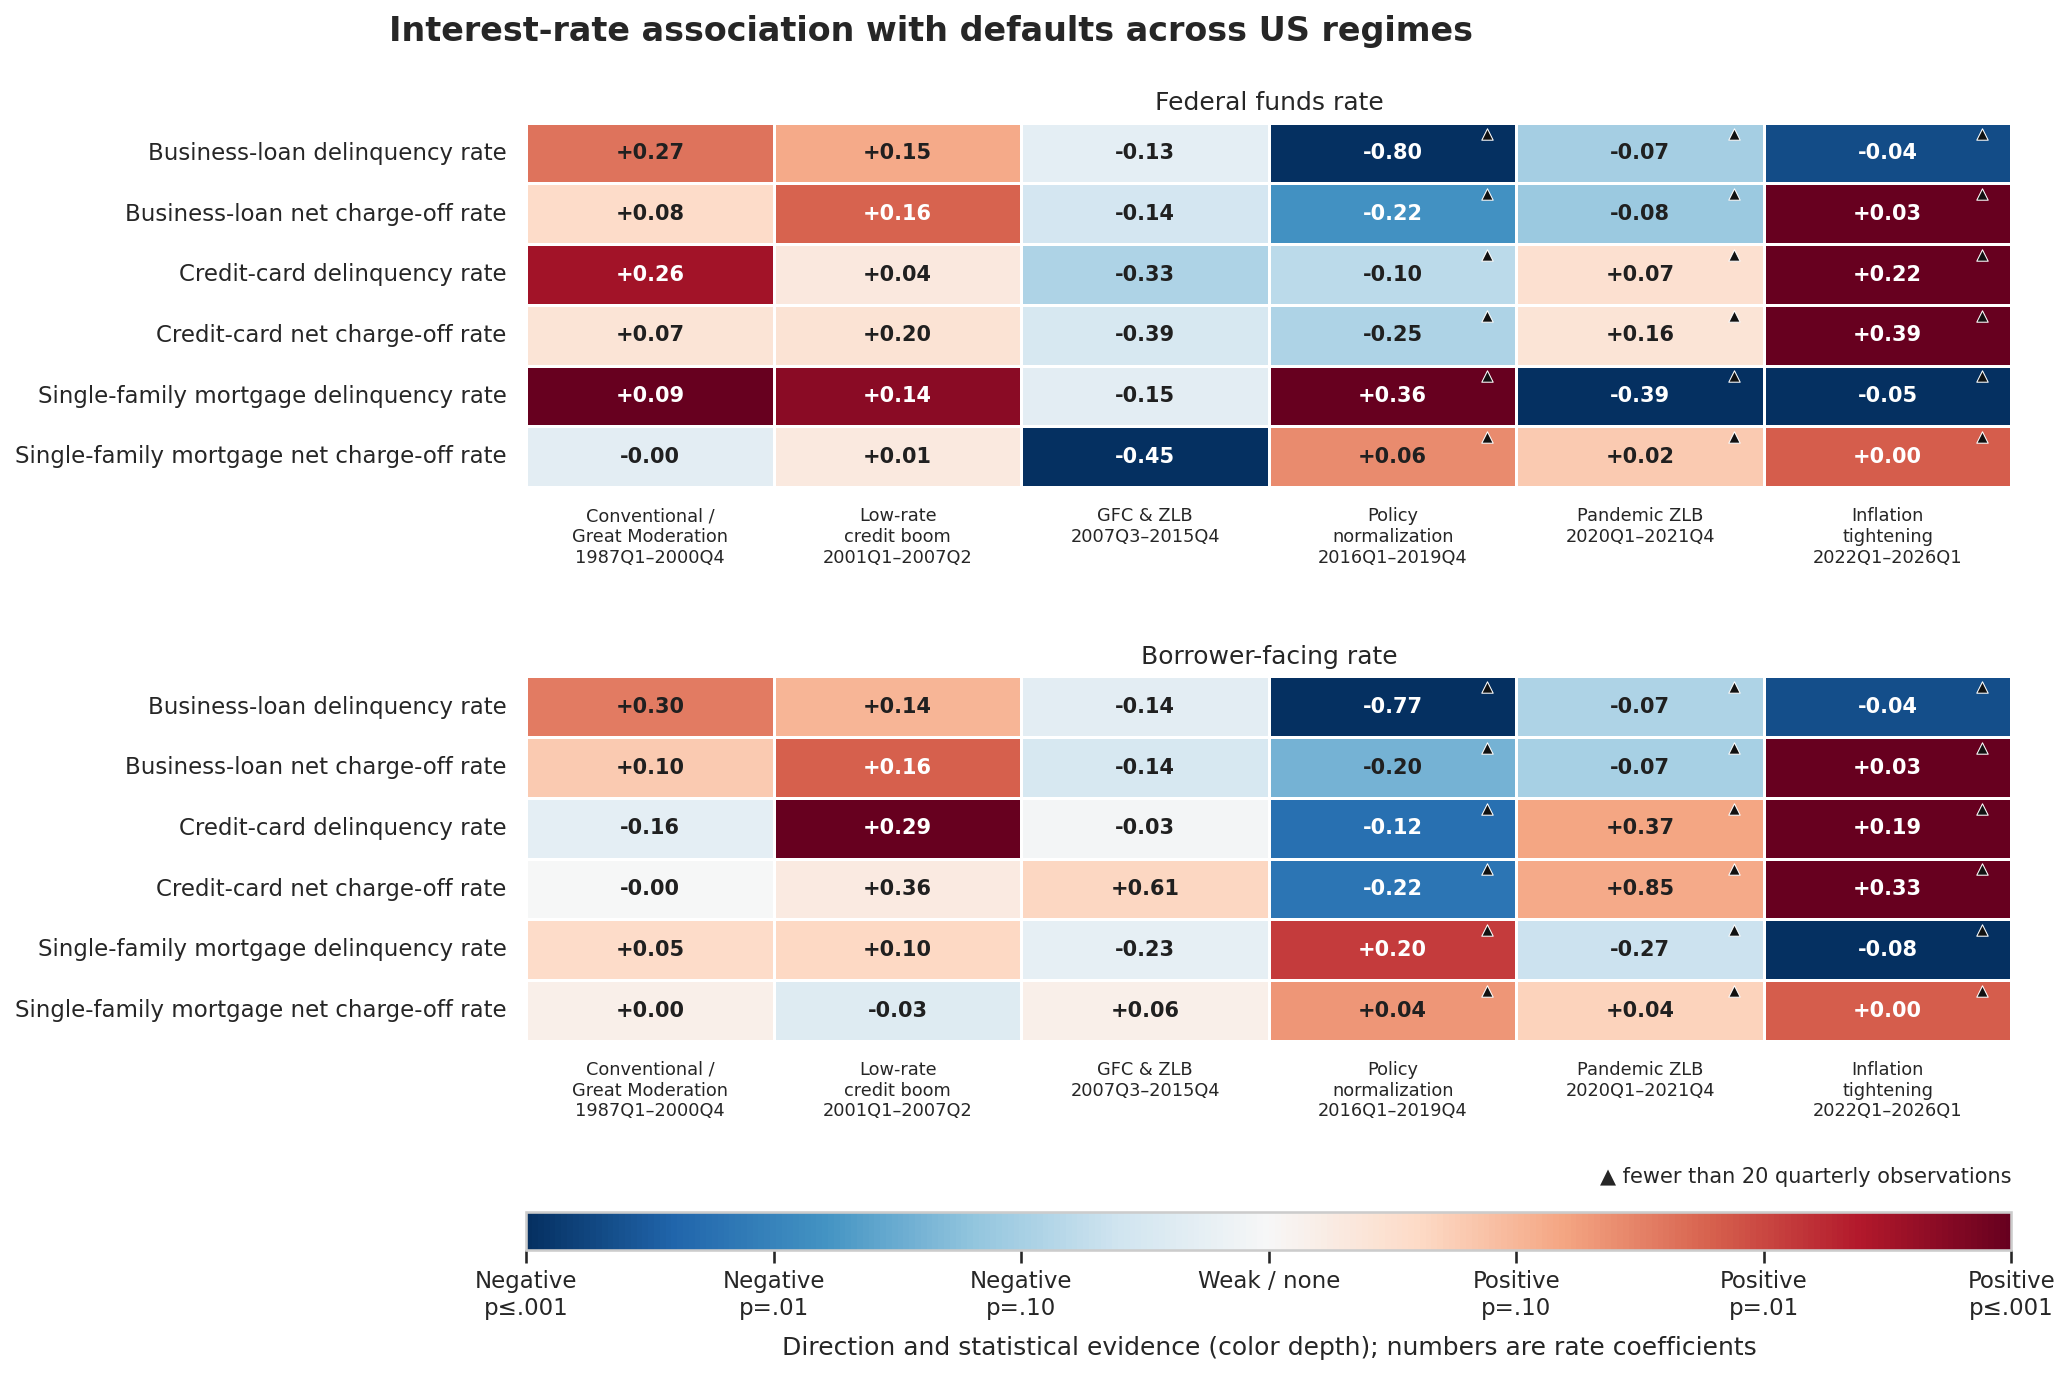

In [7]:
import matplotlib as mpl

def signed_evidence_heatmap(frame, title, ax):
    """Color = coefficient sign; depth = -log10(p), capped at p=.001."""
    x = frame[frame.specification == "Lagged change + macro controls"].copy()
    order = [r[0] for r in REGIMES]
    beta = x.pivot(index="default_definition", columns="regime", values="beta_rate").reindex(columns=order)
    pval = x.pivot(index="default_definition", columns="regime", values="p_rate").reindex(columns=order)
    nobs = x.pivot(index="default_definition", columns="regime", values="n").reindex(columns=order)

    strength = np.clip(-np.log10(pval.clip(lower=1e-12)), 0, 3)
    score = np.sign(beta) * strength
    labels = beta.map(lambda v: "" if pd.isna(v) else f"{v:+.2f}")

    sns.heatmap(score, annot=labels, fmt="", cmap="RdBu_r", center=0,
                vmin=-3, vmax=3, linewidths=1.2, linecolor="white",
                cbar=False, ax=ax, annot_kws={"fontsize": 10, "fontweight": "bold"})

    # White text on the darkest cells; black text elsewhere.
    for text, value in zip(ax.texts, score.to_numpy().ravel()):
        text.set_color("white" if np.isfinite(value) and abs(value) >= 1.7 else "#202020")

    # A triangle flags estimates based on fewer than 20 quarters.
    for i in range(nobs.shape[0]):
        for j in range(nobs.shape[1]):
            if pd.notna(nobs.iloc[i, j]) and nobs.iloc[i, j] < 20:
                ax.scatter(j + .88, i + .18, marker="^", s=30,
                           color="#111111", edgecolor="white", linewidth=.5, zorder=5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(["Conventional /\nGreat Moderation\n1987Q1–2000Q4",
                        "Low-rate\ncredit boom\n2001Q1–2007Q2",
                        "GFC & ZLB\n2007Q3–2015Q4",
                        "Policy\nnormalization\n2016Q1–2019Q4",
                        "Pandemic ZLB\n2020Q1–2021Q4",
                        "Inflation\ntightening\n2022Q1–2026Q1"],
                       rotation=0, ha="center", fontsize=8.5)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
signed_evidence_heatmap(fed_results, "Federal funds rate", axes[0])
signed_evidence_heatmap(borrower_results, "Borrower-facing rate", axes[1])

norm = mpl.colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="RdBu_r")
cax = fig.add_axes([.32, .065, .66, .028])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.set_ticklabels(["Negative\np≤.001", "Negative\np=.01", "Negative\np=.10",
                     "Weak / none", "Positive\np=.10", "Positive\np=.01", "Positive\np≤.001"])
cbar.set_label("Direction and statistical evidence (color depth); numbers are rate coefficients", labelpad=8)

fig.suptitle("Interest-rate association with defaults across US regimes", fontsize=16, fontweight="bold")
fig.text(.98, .115, "▲ fewer than 20 quarterly observations", ha="right", fontsize=10)
fig.subplots_adjust(left=.32, right=.98, top=.90, bottom=.22, hspace=.52)
plt.show()


## Rolling 10-year coefficients using absolute rates

The rolling analysis uses one common macro rate—the absolute federal funds rate—so the corporate and retail coefficients have the same units. The segment proxies are:

- **Corporate:** business-loan delinquency rate.
- **Retail:** aggregate consumer-loan delinquency rate.

For each 40-quarter rolling window, the model is:

$$DefaultRate_t = \alpha + \rho DefaultRate_{t-1} + \beta Rate_{t-L}
+ \gamma Unemployment_t + \delta GDPGrowth_t + \theta Inflation_t + \varepsilon_t$$

The first graph uses $L=4$ quarters and the second uses $L=8$ quarters. The plotted line is $\beta$: the percentage-point change in the default rate associated with a one-percentage-point higher absolute federal funds rate, conditional on the other variables. Shaded bands are approximate 95% Newey–West intervals with four lags.

Rolling windows overlap heavily, so adjacent points are not independent. The graphs describe parameter instability rather than proving structural change.

### Absolute rate lagged one year

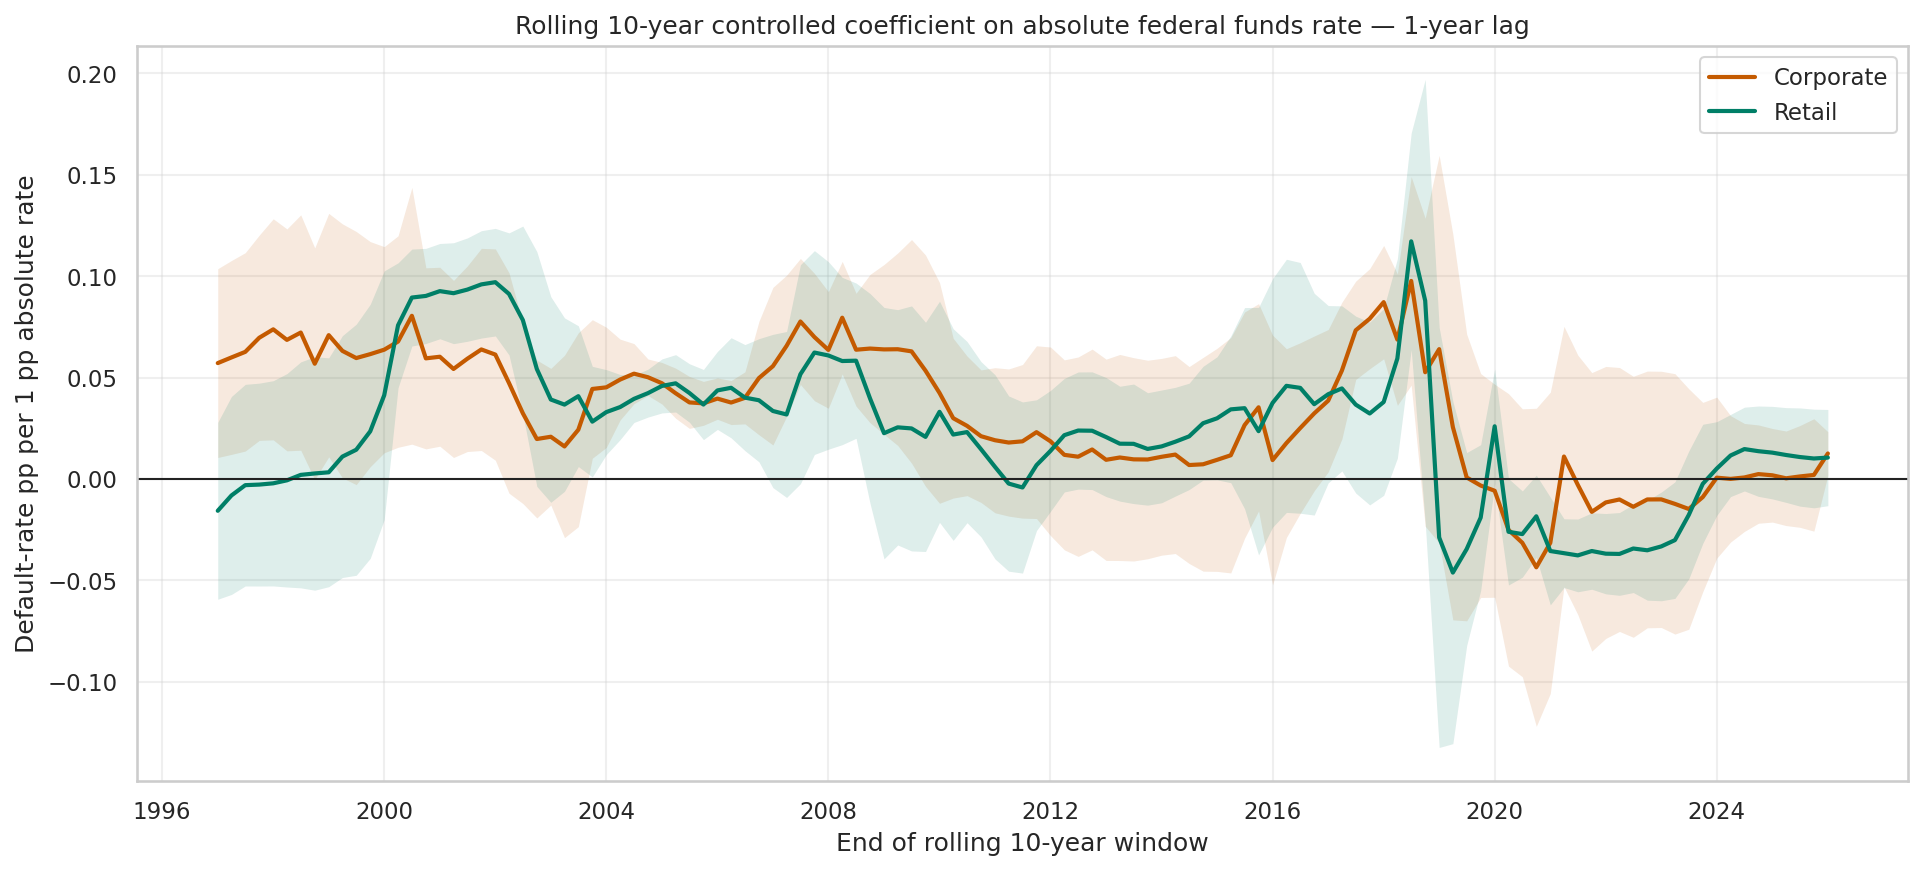

,Minimum,Median,Maximum,Sign changes
Segment,,,,
Corporate,-0.044,0.032,0.098,4
Retail,-0.046,0.024,0.117,7


In [8]:
ROLLING_SEGMENTS = {
    "Corporate": "business_delinquency",
    "Retail": "consumer_delinquency",
}

def rolling_absolute_rate_coefficients(data, lag_quarters, window=40):
    records = []
    for segment, default_col in ROLLING_SEGMENTS.items():
        model = pd.DataFrame({
            "default_rate": data[default_col],
            "default_lag1": data[default_col].shift(1),
            "rate_lag": data["fed_funds"].shift(lag_quarters),
            "unemployment": data["unemployment"],
            "gdp_growth_yoy": data["gdp_growth_yoy"],
            "inflation_yoy": data["inflation_yoy"],
        }).dropna()
        for end in range(window-1, len(model)):
            sample = model.iloc[end-window+1:end+1]
            X = np.column_stack([
                np.ones(window), sample.default_lag1, sample.rate_lag,
                sample.unemployment, sample.gdp_growth_yoy, sample.inflation_yoy,
            ])
            fit = newey_west_ols(sample.default_rate, X, maxlags=4)
            beta, se = fit[0][2], fit[1][2]
            records.append({
                "date": sample.index[-1], "segment": segment,
                "beta": beta, "se": se,
                "ci_low": beta-1.96*se, "ci_high": beta+1.96*se,
                "lag_years": lag_quarters//4,
            })
    return pd.DataFrame(records)

def rolling_summary(rolling):
    rows = []
    for segment, x in rolling.groupby("segment", sort=False):
        signs = np.sign(x.beta.to_numpy())
        rows.append({
            "Segment": segment, "Minimum": x.beta.min(),
            "Median": x.beta.median(), "Maximum": x.beta.max(),
            "Sign changes": int(np.sum(signs[1:] != signs[:-1])),
        })
    return pd.DataFrame(rows).set_index("Segment")

def plot_rolling_coefficients(rolling, lag_years, ax):
    colors = {"Corporate": "#c45a00", "Retail": "#007f67"}
    for segment, x in rolling.groupby("segment", sort=False):
        dates = x.date.dt.to_timestamp()
        ax.plot(dates, x.beta, lw=2, color=colors[segment], label=segment)
        ax.fill_between(dates, x.ci_low, x.ci_high,
                        color=colors[segment], alpha=.13, linewidth=0)
    ax.axhline(0, color="#222222", lw=1)
    ax.set_title(f"Rolling 10-year controlled coefficient on absolute federal funds rate — {lag_years}-year lag")
    ax.set_ylabel("Default-rate pp per 1 pp absolute rate")
    ax.set_xlabel("End of rolling 10-year window")
    ax.grid(alpha=.3)
    ax.legend(loc="upper right")

rolling_1y = rolling_absolute_rate_coefficients(df, 4)
rolling_2y = rolling_absolute_rate_coefficients(df, 8)
rolling_summary_1y = rolling_summary(rolling_1y)
rolling_summary_2y = rolling_summary(rolling_2y)

fig, ax = plt.subplots(figsize=(13, 6))
plot_rolling_coefficients(rolling_1y, 1, ax)
fig.tight_layout()
plt.show()
rolling_summary_1y.round(3)


### Absolute rate lagged two years

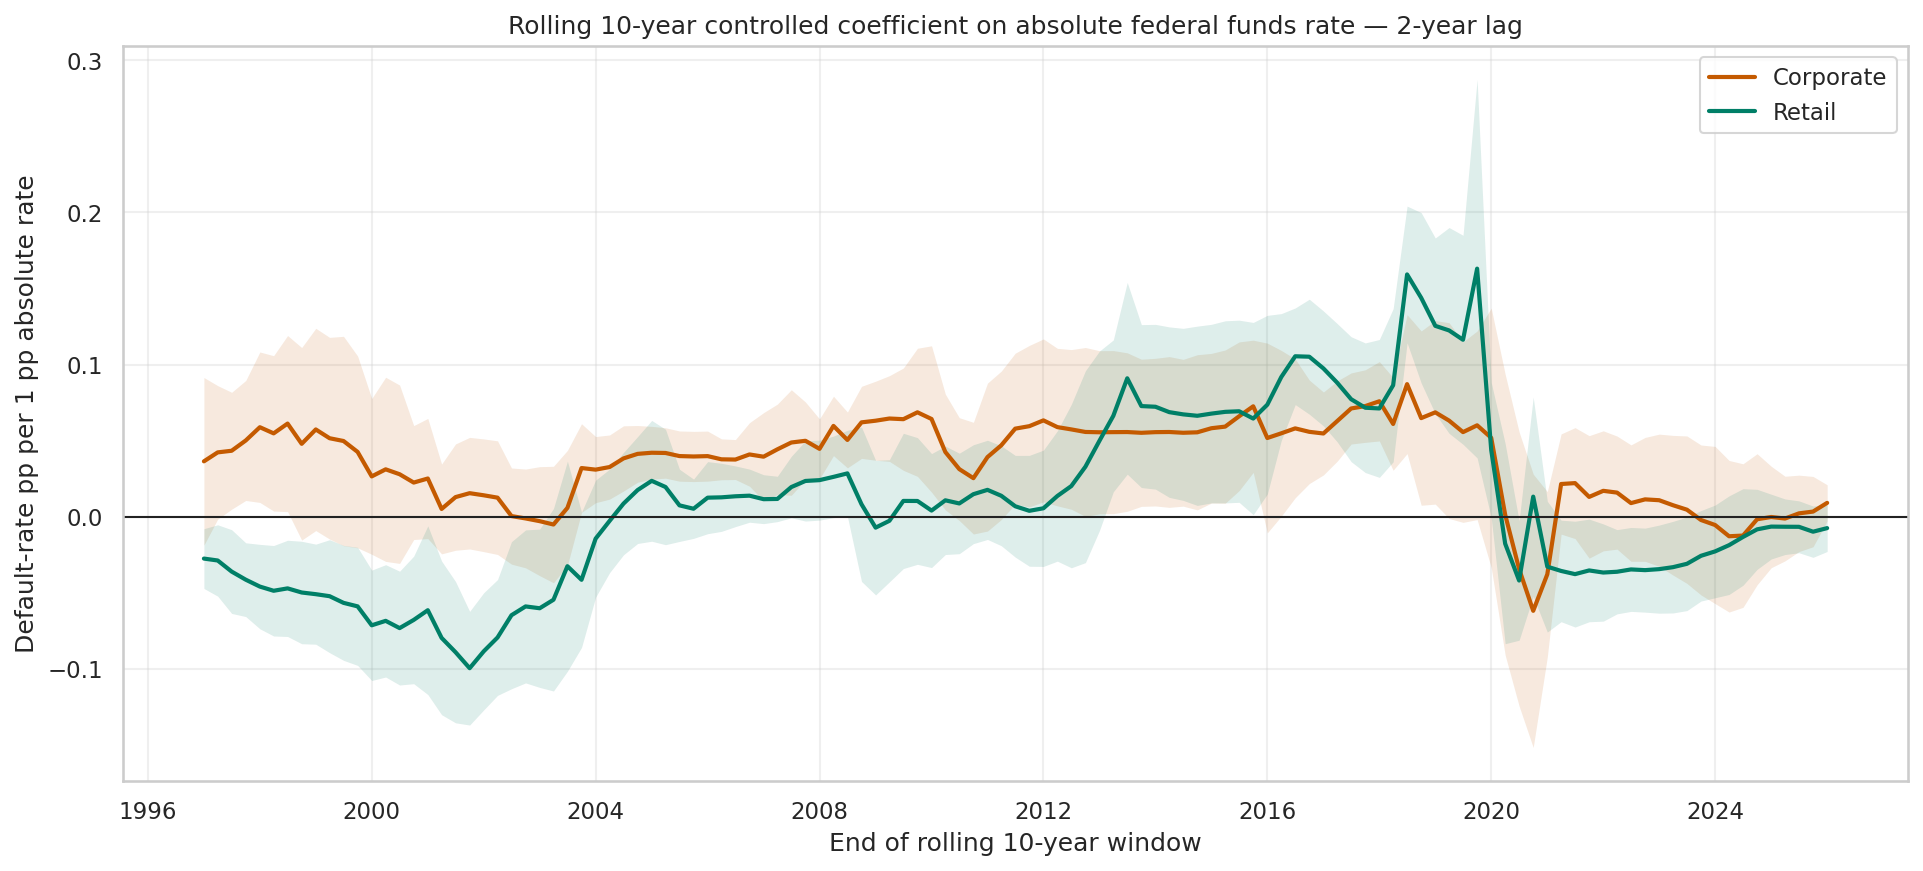

,Minimum,Median,Maximum,Sign changes
Segment,,,,
Corporate,-0.062,0.042,0.087,6
Retail,-0.100,0.005,0.163,6


In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_rolling_coefficients(rolling_2y, 2, ax)
fig.tight_layout()
plt.show()
rolling_summary_2y.round(3)


## What the calculations say

The sign is **not invariant across regimes or definitions**.

The absolute-level correlation tables generally become more positive at one- and two-year lags, but there are important exceptions—especially mortgages and the short post-2015 regimes. Because levels are persistent, these large correlations should not be read as causal effects.

In the rolling controlled models, the median one-year-lag absolute-rate coefficient is 0.032 for corporate and 0.024 for retail. At the two-year lag the medians are 0.042 and 0.005, respectively. The corporate/retail coefficients change sign 4/7 times at the one-year lag and 6/6 times at the two-year lag. The confidence bands frequently include zero, reinforcing the conclusion that the direct absolute-rate sensitivity is unstable.

- In the conventional/Great Moderation regime, five of six controlled federal-funds coefficients are positive; three are significant at 5%. The only negative estimate—mortgage charge-offs—is small and insignificant.
- In the 2001–2007 credit-boom regime, all six controlled coefficients are positive, although only business charge-offs and mortgage delinquencies are significant at 5%.
- In the GFC/ZLB regime, all six controlled coefficients are negative. This is the clearest policy-reaction regime: defaults rose while the Federal Reserve cut rates aggressively. Only the mortgage charge-off coefficient is significant at 5%.
- The normalization regime is mixed: positive for mortgage measures, negative for business and credit-card measures. It has only 16 quarterly observations.
- The pandemic period is statistically too short (8 observations) and is contaminated by payment relief, forbearance and transfers. Its coefficients should not be treated as structural.
- In the 2022–latest tightening regime, charge-offs and both credit-card measures have positive controlled coefficients, while business and mortgage delinquency coefficients are negative. Every estimate appears significant, but the regime has only 17 observations and HAC inference is unreliable in such a small sample.

The borrower-facing rate sensitivity does not eliminate the instability. In particular, a current 30-year mortgage origination rate is a poor measure of the payment burden on the outstanding stock of mostly fixed-rate mortgages.

**Interpretation:** these results support the earlier concern. A raw interest-rate coefficient is not a regime-invariant structural parameter. It mixes debt-service transmission, monetary-policy reactions, borrower composition, contractual repricing and policy interventions.


## Detailed federal-funds results

The coefficient is in percentage points of year-over-year change in the default measure per one-percentage-point lagged year-over-year increase in the federal funds rate. Confidence intervals use the reported Newey–West standard errors. Small-sample intervals should be treated cautiously.

In [10]:
detail = fed_results[fed_results.specification == "Lagged change + macro controls"].copy()
detail["Coefficient"] = detail.beta_rate.map(lambda v: f"{v:.3f}")
detail["95% CI"] = detail.apply(lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]", axis=1)
detail["p-value"] = detail.p_rate.map(lambda v: f"{v:.3f}")
detail["N"] = detail.n.astype(int)
detail["Flag"] = np.where(detail.n < 20, "Low N", "")
detail[["default_definition", "regime", "Coefficient", "95% CI", "p-value", "N", "Flag"]]


default_definition,regime,Coefficient,95% CI,p-value,N,Flag
Business-loan delinquency rate,Conventional / Great Moderation,0.273,"[0.045, 0.502]",0.023,52,
Business-loan delinquency rate,Low-rate credit boom,0.145,"[-0.006, 0.297]",0.074,26,
Business-loan delinquency rate,GFC and ZLB,-0.126,"[-0.488, 0.236]",0.500,34,
Business-loan delinquency rate,Policy normalization,-0.798,"[-1.084, -0.513]",0.000,16,Low N
Business-loan delinquency rate,Pandemic ZLB,-0.070,"[-0.134, -0.007]",0.096,8,Low N
Business-loan delinquency rate,Inflation tightening,-0.040,"[-0.061, -0.020]",0.002,17,Low N
Business-loan net charge-off rate,Conventional / Great Moderation,0.075,"[-0.054, 0.205]",0.260,56,
Business-loan net charge-off rate,Low-rate credit boom,0.163,"[0.040, 0.286]",0.017,26,
Business-loan net charge-off rate,GFC and ZLB,-0.145,"[-0.400, 0.110]",0.275,34,
Business-loan net charge-off rate,Policy normalization,-0.215,"[-0.364, -0.066]",0.015,16,Low N


## Implications for an IFRS 9 macro model

1. **Do not estimate one universal raw-rate coefficient.** The US aggregate data reject the idea that its sign is stable across policy episodes.
2. **Model the transmission channel.** Payment reset, refinancing burden, interest coverage and debt-service ratios are more structural than the policy rate.
3. **Segment contractual exposure.** Fixed-rate mortgages should not have the same short-run sensitivity as floating-rate corporate or credit-card debt.
4. **Treat GFC and pandemic observations explicitly.** Policy responses, forbearance and transfers break ordinary historical relationships.
5. **Do not infer causality from these regressions.** A causal study would require identified monetary-policy shocks, instruments or a structural model.
6. **Validate across held-out regimes.** A candidate IFRS 9 specification should be trained on some episodes and tested on an economically different episode.

The practical conclusion is not that interest rates are unusable. It is that the policy rate works better as a scenario input feeding borrower cash-flow variables than as a universal direct PD regressor.

## Important limitations and extensions

- Public quarterly bank data begin in 1985–1991, so this is a roughly 35–40 year study, not a century-long corporate bond study.
- Moody's corporate default data extend to 1920 and the Giesecke–Longstaff–Schaefer–Strebulaev research dataset extends to 1866, but the underlying updated series is not included because it is not a straightforward public FRED dataset.
- Aggregation changes the composition of borrowers over time. A falling aggregate mortgage delinquency rate can coexist with severe stress among recent vintages.
- The relevant rate is the rate that actually reprices borrower cash flows. Prime, mortgage and average card rates are still imperfect proxies.
- Regimes are short, especially after 2015. Apparent significance in 8–17 observations should not be used for model calibration.
- A stronger next stage would use vintage-level mortgage data, bank Call Reports, corporate maturity schedules, floating-rate shares, and identified monetary-policy shocks.

For a causal interpretation, replace observed rate changes with a documented monetary-policy shock series and estimate local projections. For an IFRS 9 application, replace the aggregate policy rate with forecast payment burden or interest coverage at the portfolio-segment level.